In [1]:
import pickle

In [2]:
with open('models/processed_data.pkl','rb') as f:
    data = pickle.load(f)

X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']

print(X_train.shape , X_test.shape , y_train.shape , y_test.shape)

(1972, 43) (294, 43) (1972,) (294,)


LOGISTIC REGRESSION

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , precision_score , recall_score , f1_score , roc_auc_score , classification_report

In [4]:
log_reg = LogisticRegression(random_state = 42 , max_iter = 1000)
log_reg.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [5]:
y_pred = log_reg.predict(X_test)
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]

In [6]:
print('Accuracy:', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred))
print('F1:', f1_score(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, y_pred_proba))
print("\n", classification_report(y_test, y_pred))

Accuracy: 0.7687074829931972
Precision: 0.36363636363636365
Recall: 0.5957446808510638
F1: 0.45161290322580644
ROC-AUC: 0.7902489447842191

               precision    recall  f1-score   support

           0       0.91      0.80      0.85       247
           1       0.36      0.60      0.45        47

    accuracy                           0.77       294
   macro avg       0.64      0.70      0.65       294
weighted avg       0.82      0.77      0.79       294



K-NEAREST NEIGHBORS

In [7]:
from sklearn.neighbors import KNeighborsClassifier

In [8]:
knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [9]:
y_pred_knn = knn.predict(X_test)
y_pred_proba_knn = knn.predict_proba(X_test)[:,1]

In [10]:
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1:", f1_score(y_test, y_pred_knn))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_knn))
print("\n", classification_report(y_test, y_pred_knn))

Accuracy: 0.6326530612244898
Precision: 0.23008849557522124
Recall: 0.5531914893617021
F1: 0.325
ROC-AUC: 0.6134464639503833

               precision    recall  f1-score   support

           0       0.88      0.65      0.75       247
           1       0.23      0.55      0.33        47

    accuracy                           0.63       294
   macro avg       0.56      0.60      0.54       294
weighted avg       0.78      0.63      0.68       294



NAIVE BAYES

In [11]:
from sklearn.naive_bayes import GaussianNB

In [12]:
nb = GaussianNB()
nb.fit(X_train,y_train)

,priors,None
,var_smoothing,1e-09


In [13]:
y_pred_nb = nb.predict(X_test)
y_pred_proba_nb = nb.predict_proba(X_test)[:,1]

In [14]:
print("Accuracy:", accuracy_score(y_test,y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall:", recall_score(y_test, y_pred_nb))
print("F1:", f1_score(y_test, y_pred_nb))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_nb))
print("\n", classification_report(y_test, y_pred_nb))

Accuracy: 0.4965986394557823
Precision: 0.19760479041916168
Recall: 0.7021276595744681
F1: 0.308411214953271
ROC-AUC: 0.6440692566112498

               precision    recall  f1-score   support

           0       0.89      0.46      0.60       247
           1       0.20      0.70      0.31        47

    accuracy                           0.50       294
   macro avg       0.54      0.58      0.46       294
weighted avg       0.78      0.50      0.56       294



RANDOM FOREST 

In [15]:
from sklearn.ensemble import RandomForestClassifier

In [16]:
rf = RandomForestClassifier(random_state = 42)
rf.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [17]:
y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:,1]

In [18]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_rf))
print("\n", classification_report(y_test, y_pred_rf))

Accuracy: 0.8333333333333334
Precision: 0.4583333333333333
Recall: 0.23404255319148937
F1: 0.30985915492957744
ROC-AUC: 0.8012748729434059

               precision    recall  f1-score   support

           0       0.87      0.95      0.91       247
           1       0.46      0.23      0.31        47

    accuracy                           0.83       294
   macro avg       0.66      0.59      0.61       294
weighted avg       0.80      0.83      0.81       294



XGBOOST

In [19]:
from xgboost import XGBClassifier

In [20]:
xgb = XGBClassifier(random_state = 42 , eval_metric = 'logloss')
xgb.fit(X_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [21]:
y_pred_xgb = xgb.predict(X_test)
y_pred_proba_xgb = xgb.predict_proba(X_test)[:,1]

In [22]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1:", f1_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_xgb))
print("\n", classification_report(y_test, y_pred_xgb))

Accuracy: 0.8639455782312925
Precision: 0.6666666666666666
Recall: 0.2978723404255319
F1: 0.4117647058823529
ROC-AUC: 0.7950727883538634

               precision    recall  f1-score   support

           0       0.88      0.97      0.92       247
           1       0.67      0.30      0.41        47

    accuracy                           0.86       294
   macro avg       0.77      0.63      0.67       294
weighted avg       0.85      0.86      0.84       294



Building a Comparison Table

In [23]:
import pandas as pd

In [24]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'Naive Bayes', 'Random Forest', 'XGBoost'],
    'Accuracy': [0.769, 0.633, 0.497, 0.833, 0.864],
    'Precision': [0.36, 0.23, 0.20, 0.46, 0.67],
    'Recall': [0.60, 0.55, 0.70, 0.23, 0.30],
    'F1': [0.45, 0.33, 0.31, 0.31, 0.41],
    'ROC-AUC': [0.790, 0.613, 0.644, 0.80, 0.795]
})

print(results.sort_values('ROC-AUC', ascending=False))

                 Model  Accuracy  Precision  Recall    F1  ROC-AUC
3        Random Forest     0.833       0.46    0.23  0.31    0.800
4              XGBoost     0.864       0.67    0.30  0.41    0.795
0  Logistic Regression     0.769       0.36    0.60  0.45    0.790
2          Naive Bayes     0.497       0.20    0.70  0.31    0.644
1                  KNN     0.633       0.23    0.55  0.33    0.613


ROC Curve

In [25]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

In [26]:
fpr_lr, tpr_lr, _  = roc_curve(y_test,y_pred_proba)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_pred_proba_knn)
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_pred_proba_nb)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)

In [30]:
roc_data = {
    'Logistic Regression': {'fpr': fpr_lr, 'tpr': tpr_lr, 'auc': 0.790},
    'KNN': {'fpr': fpr_knn, 'tpr': tpr_knn, 'auc': 0.613},
    'Naive Bayes': {'fpr': fpr_nb, 'tpr': tpr_nb, 'auc': 0.644},
    'Random Forest': {'fpr': fpr_rf, 'tpr': tpr_rf, 'auc': 0.80},
    'XGBoost': {'fpr': fpr_xgb, 'tpr': tpr_xgb, 'auc': 0.795},
}

In [31]:
with open('models/roc_data.pkl','wb') as f:
    pickle.dump(roc_data, f)

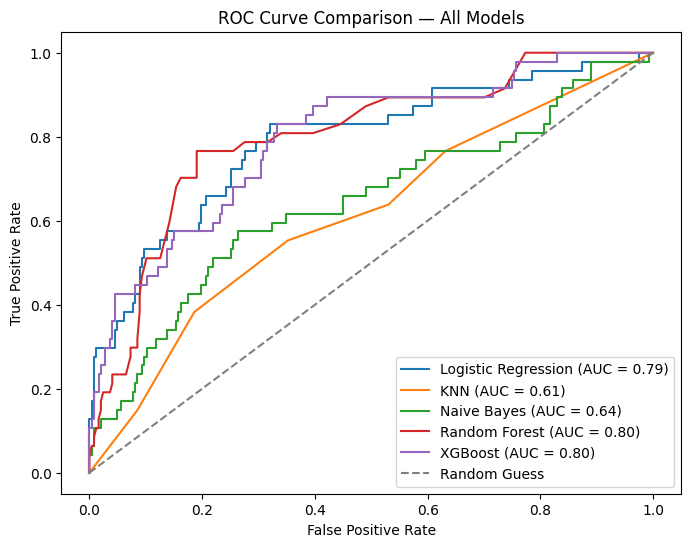

In [27]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label='Logistic Regression (AUC = 0.79)')
plt.plot(fpr_knn, tpr_knn, label='KNN (AUC = 0.61)')
plt.plot(fpr_nb, tpr_nb, label='Naive Bayes (AUC = 0.64)')
plt.plot(fpr_rf, tpr_rf, label='Random Forest (AUC = 0.80)')
plt.plot(fpr_xgb, tpr_xgb, label='XGBoost (AUC = 0.80)')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison — All Models')
plt.legend()
plt.show()

Trying a threshold of 0.3 (earlier threshold = 0.5)

In [28]:
new_threshold = 0.3
y_pred_xgb_adjusted = (y_pred_proba_xgb >= new_threshold).astype(int)

In [29]:
print(f"--- XGBoost at threshold = {new_threshold} ---")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb_adjusted))
print("Precision:", precision_score(y_test, y_pred_xgb_adjusted))
print("Recall:", recall_score(y_test, y_pred_xgb_adjusted))
print("F1:", f1_score(y_test, y_pred_xgb_adjusted))
print("\n", classification_report(y_test, y_pred_xgb_adjusted))

--- XGBoost at threshold = 0.3 ---
Accuracy: 0.8707482993197279
Precision: 0.6451612903225806
Recall: 0.425531914893617
F1: 0.5128205128205128

               precision    recall  f1-score   support

           0       0.90      0.96      0.93       247
           1       0.65      0.43      0.51        47

    accuracy                           0.87       294
   macro avg       0.77      0.69      0.72       294
weighted avg       0.86      0.87      0.86       294



XGBoost was selected as the best model — while its default threshold (0.5) under-predicted attrition, adjusting the classification threshold to ~0.3 improved F1 to 0.513 (surpassing Logistic Regression's 0.45) by better balancing precision and recall, while also retaining the highest ROC-AUC (0.795) among all models tested.